In [1]:

%pylab inline
import numpy as np
from tqdm import trange
np.set_printoptions(suppress=True)

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [3]:

# load the mnist dataset

def fetch(url):
    import requests, gzip, os, hashlib, numpy
    fp = os.path.join("/tmp", hashlib.md5(url.encode('utf-8')).hexdigest())
    if os.path.isfile(fp):
        with open(fp, "rb") as f:
            dat = f.read()
    else:
        with open(fp, "wb") as f:
            dat = requests.get(url).content
            f.write(dat)
    return numpy.frombuffer(gzip.decompress(dat), dtype=np.uint8).copy()
X_train = fetch("http://yann.lecun.com/exdb/mnist/train-images-idx3-ubyte.gz")[0x10:].reshape((-1, 28, 28))
Y_train = fetch("http://yann.lecun.com/exdb/mnist/train-labels-idx1-ubyte.gz")[8:]
X_test = fetch("http://yann.lecun.com/exdb/mnist/t10k-images-idx3-ubyte.gz")[0x10:].reshape((-1, 28, 28))
Y_test = fetch("http://yann.lecun.com/exdb/mnist/t10k-labels-idx1-ubyte.gz")[8:]

In [4]:
# model
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.set_printoptions(sci_mode=False)
class BobNet(torch.nn.Module):
  def __init__(self):
    super(BobNet, self).__init__()
    self.l1 = nn.Linear(784, 128, bias=False)
    self.l2 = nn.Linear(128, 10, bias=False)
    self.sm = nn.LogSoftmax(dim=1)
  def forward(self, x):
    x = F.relu(self.l1(x))
    x = self.l2(x)
    x = self.sm(x)
    return x

loss 0.77 accuracy 0.77:   3%|▍              | 30/1000 [00:00<00:03, 298.54it/s]

tensor([8, 6, 1, 8, 6, 0, 7, 9, 1, 7, 1, 7, 4, 1, 0, 5, 2, 7, 5, 5, 3, 1, 6, 3,
        7, 3, 1, 4, 8, 0, 3, 6, 8, 7, 5, 0, 2, 8, 0, 5, 5, 2, 6, 9, 3, 8, 0, 1,
        5, 1, 5, 4, 0, 0, 7, 7, 9, 2, 7, 6, 3, 4, 0, 1, 0, 4, 9, 5, 3, 8, 0, 6,
        0, 8, 6, 7, 5, 2, 8, 5, 3, 6, 8, 9, 7, 9, 8, 6, 4, 1, 3, 8, 7, 9, 9, 8,
        3, 7, 7, 1, 5, 3, 4, 0, 2, 5, 7, 3, 6, 0, 3, 4, 9, 7, 1, 3, 1, 9, 6, 2,
        9, 1, 5, 2, 9, 2, 2, 2])
tensor([5, 3, 2, 8, 1, 5, 3, 7, 2, 3, 1, 3, 9, 3, 4, 1, 5, 7, 7, 2, 8, 4, 3, 4,
        2, 9, 3, 1, 6, 3, 2, 9, 2, 3, 9, 3, 0, 8, 2, 9, 4, 8, 8, 3, 1, 4, 7, 0,
        1, 3, 6, 0, 0, 0, 0, 0, 8, 2, 4, 8, 3, 3, 7, 3, 9, 6, 5, 8, 2, 1, 0, 4,
        2, 4, 1, 2, 3, 4, 6, 3, 6, 3, 6, 5, 4, 2, 9, 8, 4, 0, 5, 9, 4, 2, 1, 3,
        3, 0, 5, 6, 2, 3, 7, 5, 4, 8, 6, 7, 2, 5, 9, 2, 2, 9, 7, 4, 2, 7, 7, 1,
        8, 0, 1, 7, 0, 4, 0, 5])
tensor([7, 1, 5, 3, 4, 0, 7, 7, 3, 2, 2, 2, 6, 3, 3, 9, 6, 1, 3, 4, 5, 3, 8, 8,
        9, 8, 9, 1, 2, 9, 5, 7, 8, 1, 6, 5, 0, 4, 7, 7

loss 0.51 accuracy 0.87:  10%|█▍             | 99/1000 [00:00<00:02, 314.60it/s]

tensor([9, 9, 1, 9, 1, 4, 3, 0, 0, 0, 1, 3, 7, 3, 2, 5, 4, 8, 0, 7, 3, 9, 0, 1,
        3, 5, 0, 8, 6, 2, 7, 2, 8, 8, 2, 4, 6, 0, 4, 7, 0, 0, 1, 1, 0, 5, 4, 7,
        6, 7, 2, 6, 1, 2, 7, 6, 1, 4, 3, 6, 5, 7, 8, 1, 1, 8, 1, 3, 1, 1, 5, 0,
        8, 0, 7, 7, 2, 4, 3, 4, 8, 6, 3, 2, 9, 6, 7, 0, 0, 9, 6, 4, 7, 5, 4, 0,
        7, 4, 8, 9, 5, 0, 3, 0, 7, 2, 4, 1, 8, 4, 7, 9, 8, 1, 2, 3, 0, 7, 6, 2,
        8, 8, 8, 8, 5, 5, 5, 4])
tensor([9, 6, 4, 0, 7, 7, 1, 6, 9, 2, 5, 4, 1, 6, 0, 7, 0, 9, 0, 3, 7, 1, 2, 3,
        6, 7, 9, 1, 6, 1, 6, 7, 4, 4, 8, 1, 5, 6, 8, 0, 3, 8, 9, 0, 4, 6, 3, 8,
        9, 8, 0, 2, 3, 3, 4, 8, 8, 8, 3, 5, 2, 8, 1, 6, 3, 1, 2, 2, 5, 8, 9, 0,
        1, 7, 2, 3, 7, 2, 3, 0, 8, 9, 3, 5, 8, 4, 1, 0, 7, 5, 4, 0, 6, 7, 6, 0,
        7, 9, 3, 7, 6, 4, 6, 3, 1, 0, 6, 6, 7, 8, 1, 4, 3, 8, 9, 8, 8, 9, 6, 0,
        4, 6, 2, 6, 1, 6, 7, 4])
tensor([7, 0, 0, 3, 4, 0, 2, 5, 8, 8, 7, 6, 5, 9, 9, 5, 7, 2, 2, 7, 4, 8, 5, 7,
        8, 9, 5, 6, 6, 4, 1, 6, 7, 5, 7, 5, 6, 1, 8, 3

loss 0.58 accuracy 0.86:  18%|██▍           | 177/1000 [00:00<00:02, 357.66it/s]

...

tensor([7, 4, 8, 5, 4, 3, 8, 7, 8, 5, 9, 1, 6, 6, 3, 8, 0, 9, 4, 7, 0, 3, 0, 5,
        9, 7, 2, 2, 9, 5, 5, 4, 3, 5, 9, 2, 6, 5, 7, 6, 4, 3, 9, 8, 6, 7, 0, 2,
        2, 7, 0, 3, 5, 6, 5, 2, 8, 0, 5, 2, 7, 0, 7, 5, 4, 3, 4, 6, 5, 6, 2, 9,
        9, 3, 3, 5, 7, 1, 1, 9, 4, 1, 7, 9, 7, 0, 3, 1, 6, 8, 6, 0, 9, 3, 2, 8,
        4, 7, 2, 4, 7, 6, 0, 2, 8, 5, 7, 0, 0, 6, 5, 0, 6, 1, 3, 2, 6, 2, 3, 0,
        4, 2, 8, 1, 0, 1, 1, 4])
tensor([1, 8, 1, 1, 9, 5, 8, 4, 5, 7, 4, 1, 2, 5, 1, 8, 3, 0, 0, 9, 4, 3, 5, 6,
        1, 7, 6, 4, 9, 2, 1, 9, 3, 6, 8, 5, 7, 6, 3, 3, 7, 5, 2, 1, 1, 5, 7, 1,
        8, 9, 0, 8, 2, 1, 1, 7, 6, 2, 3, 7, 5, 0, 3, 2, 6, 9, 7, 7, 1, 8, 6, 2,
        1, 4, 3, 2, 3, 1, 8, 0, 4, 0, 5, 0, 2, 1, 2, 9, 1, 5, 2, 3, 4, 4, 5, 1,
        0, 7, 5, 6, 3, 6, 7, 3, 6, 4, 4, 2, 5, 1, 7, 1, 3, 6, 2, 9, 0, 2, 6, 7,
        2, 2, 0, 2, 1, 7, 3, 2])
tensor([6, 5, 2, 7, 3, 1, 4, 7, 0, 7, 7, 0, 2, 3, 6, 6, 1, 5, 1, 7, 1, 5, 1, 4,
        5, 7, 7, 1, 8, 1, 6, 5, 6, 4, 1, 1, 9, 6, 7, 8

loss 0.25 accuracy 0.95:  94%|█████████████▏| 938/1000 [00:02<00:00, 364.70it/s]

tensor([1, 7, 8, 5, 9, 9, 7, 4, 3, 6, 1, 4, 9, 8, 8, 6, 1, 7, 0, 6, 3, 9, 1, 2,
        7, 5, 4, 1, 6, 3, 5, 6, 6, 7, 1, 8, 8, 0, 0, 8, 9, 2, 1, 4, 0, 6, 2, 5,
        7, 0, 6, 3, 7, 3, 8, 6, 2, 3, 3, 3, 4, 0, 1, 6, 3, 2, 8, 2, 7, 9, 8, 0,
        3, 8, 3, 2, 0, 9, 6, 7, 4, 6, 3, 4, 9, 6, 0, 6, 6, 7, 5, 0, 2, 9, 2, 4,
        7, 2, 7, 9, 2, 2, 1, 6, 7, 7, 2, 5, 1, 5, 5, 8, 4, 7, 3, 5, 0, 8, 5, 8,
        4, 9, 3, 6, 8, 5, 7, 2])
tensor([4, 4, 9, 0, 7, 3, 3, 8, 7, 1, 3, 3, 7, 1, 3, 0, 3, 5, 1, 1, 3, 9, 3, 2,
        3, 3, 9, 7, 5, 0, 7, 7, 6, 7, 3, 8, 9, 5, 2, 7, 1, 3, 7, 3, 8, 6, 4, 9,
        2, 3, 9, 2, 4, 3, 0, 6, 2, 1, 1, 6, 0, 2, 4, 8, 1, 5, 2, 9, 0, 7, 2, 1,
        5, 8, 9, 6, 5, 1, 0, 7, 0, 4, 2, 9, 1, 9, 8, 8, 4, 3, 8, 8, 2, 1, 7, 3,
        2, 4, 5, 0, 5, 2, 7, 4, 5, 9, 9, 8, 4, 3, 0, 1, 7, 9, 2, 6, 7, 1, 1, 9,
        2, 5, 8, 1, 9, 3, 4, 2])
tensor([8, 7, 3, 7, 6, 4, 4, 6, 9, 1, 9, 5, 8, 4, 5, 1, 6, 2, 3, 5, 9, 4, 6, 1,
        5, 3, 2, 0, 4, 9, 5, 9, 5, 4, 3, 8, 4, 1, 5, 1

loss 0.10 accuracy 0.98: 100%|█████████████| 1000/1000 [00:02<00:00, 363.61it/s]


tensor([7, 6, 0, 1, 9, 9, 1, 2, 8, 1, 1, 8, 3, 2, 1, 4, 5, 4, 1, 4, 7, 2, 9, 5,
        1, 4, 2, 3, 4, 9, 3, 2, 4, 0, 9, 6, 2, 8, 6, 1, 5, 9, 0, 3, 7, 9, 0, 4,
        3, 7, 8, 1, 8, 3, 0, 9, 2, 8, 9, 7, 5, 8, 6, 0, 2, 6, 8, 4, 7, 4, 3, 4,
        7, 1, 6, 8, 2, 1, 7, 6, 5, 2, 4, 8, 9, 6, 1, 3, 6, 0, 9, 4, 7, 8, 8, 9,
        6, 3, 0, 4, 8, 0, 4, 4, 1, 0, 6, 5, 1, 6, 9, 3, 2, 2, 7, 1, 9, 2, 4, 6,
        2, 9, 7, 3, 9, 4, 2, 2])
tensor([7, 1, 9, 0, 3, 7, 4, 7, 6, 7, 8, 5, 0, 4, 5, 8, 0, 1, 8, 3, 5, 8, 5, 8,
        9, 2, 1, 3, 7, 5, 0, 0, 1, 4, 7, 1, 9, 8, 2, 1, 4, 3, 6, 9, 3, 8, 0, 0,
        5, 1, 2, 3, 9, 3, 1, 0, 4, 9, 2, 2, 1, 6, 6, 5, 6, 1, 0, 7, 9, 2, 2, 7,
        6, 7, 5, 4, 5, 7, 1, 2, 2, 7, 4, 3, 4, 0, 9, 6, 9, 4, 0, 2, 4, 3, 4, 0,
        9, 8, 8, 9, 1, 6, 3, 0, 0, 6, 1, 4, 9, 1, 7, 5, 1, 9, 4, 7, 5, 1, 9, 5,
        6, 2, 8, 7, 2, 5, 3, 3])
tensor([8, 4, 9, 6, 9, 5, 4, 6, 1, 8, 7, 1, 3, 7, 7, 8, 8, 6, 2, 4, 5, 4, 5, 2,
        1, 6, 1, 6, 8, 0, 1, 9, 9, 6, 8, 8, 4, 7, 1, 7

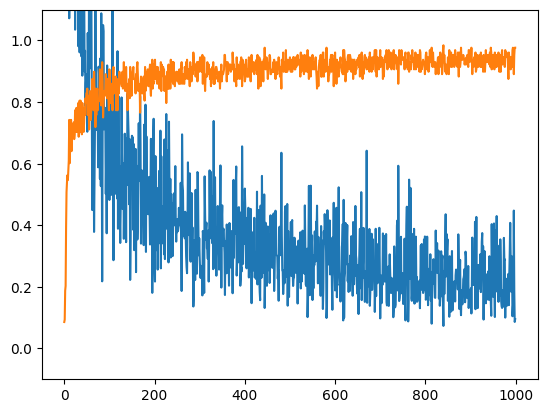

In [8]:
# training
model = BobNet()

# protip: if you like accuracy like 96 not like 93, next time through the notebook, consider
# CHAD MODE WEIGHT INIT WITH NUMPY
# instead of virgin torch init mode
# TODO: why is torch linear init bad?
"""
with torch.no_grad():
  model.l1.weight.copy_(torch.tensor(layer_init(784, 128).T))
  model.l2.weight.copy_(torch.tensor(layer_init(128, 10).T))
"""

loss_function = nn.NLLLoss(reduction='none')
optim = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0)
BS = 128
losses, accuracies = [], []
for i in (t := trange(1000)):
  samp = np.random.randint(0, X_train.shape[0], size=(BS))
  X = torch.tensor(X_train[samp].reshape((-1, 28*28))).float()
  Y = torch.tensor(Y_train[samp]).long()
  print(Y)
  model.zero_grad()
  out = model(X)
  cat = torch.argmax(out, dim=1)
  accuracy = (cat == Y).float().mean()
  loss = loss_function(out, Y)
  loss = loss.mean()
  loss.backward()
  optim.step()
  loss, accuracy = loss.item(), accuracy.item()
  losses.append(loss)
  accuracies.append(accuracy)
  t.set_description("loss %.2f accuracy %.2f" % (loss, accuracy))
plt.ylim(-0.1, 1.1)
plot(losses)
plot(accuracies)